In [1]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

In [2]:
# Number of time steps
T = 1000

# Variance (!) of the noise getting added in each step
betas = torch.linspace(1e-4,0.02,T)

# Complements of noises, how much signal survives in each step
alphas = 1 - betas

# Cumulative products of alphas. entry t is the a_1 \cdot \dots \cdot a_t
# How much of the original image survives after t steps
alpha_bars = torch.cumprod(alphas, dim=0)


In [3]:
assert torch.allclose(betas[0], torch.tensor(1e-4), atol=1e-8), f"betas should start at 1e-4, got {betas[0].item()}"
assert torch.allclose(alpha_bars[-1], torch.tensor(4e-05), atol=1e-4), f"alpha_bars should end at 4e-05, got {alpha_bars[-1].item()}"
assert (alpha_bars[1:] < alpha_bars[:-1]).all(), "alpha_bars are not strictly decreasing"
print("schedule OK")

schedule OK


# (B,C,H,W)
We will work on (128, 1, 32, 32)

B: Batch size

C: Channels (1 if grayscale, 3 if RGB)

H: Height

W: Width


In [4]:
tf = transforms.Compose([
    transforms.ToTensor(),                 # PIL uint8 [0,255] HWC -> float32 [0,1] CHW, (1,28,28)
    transforms.Pad(2),                     # -> (1,32,32); fill=0 is black, matches background
    transforms.Normalize((0.5,), (0.5,)),  # (x - 0.5) / 0.5  ->  [-1,1]
])

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=tf)

In [5]:
print(f"size of data: {len(train_ds)}")
print(f"shape of images: {train_ds[0][0].shape}")
print("\n")

img, label = train_ds[0]
print(f"label of first image: {label}")
print(f"max value of first image: {img.max()}")
print(f"min value of first image: {img.min()}")

size of data: 60000
shape of images: torch.Size([1, 32, 32])


label of first image: 5
max value of first image: 1.0
min value of first image: -1.0


In [6]:
def q_sample(x_0, t):
    # 1. draw the noise                          -> (B, 1, 32, 32)
    eps = torch.randn(x_0.shape, dtype=x_0.dtype, device=x_0.device)

    # 2. look up alpha_bar for each t in the batch  -> (B,)
    ab = alpha_bars[t]

    # 3. reshape so it broadcasts over images     -> (B, 1, 1, 1)
    ab = ab.view(x_0.shape[0], 1, 1, 1)
    # OR I could have said 'ab = ab.view(-1, 1, 1, 1)' instead. This is also a shorter notation apparently

    # 4. the closed form
    x_t = ab.sqrt() * x_0 + (1-ab).sqrt()* eps

    return x_t, eps


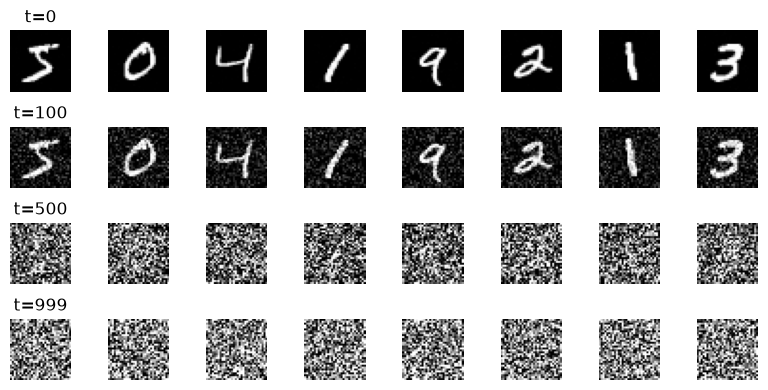

In [7]:
# Let's get the first 8 images for example
# Note that the train_ds holds tuples as (image, label), so we collect the first element of the tuples
imgs = [train_ds[i][0] for i in range(8)]
x_0 = torch.stack(imgs)

fig, axes = plt.subplots(4, 8, figsize=(8, 4))

timesteps = [0, 100, 500, 999]

for r, tv in enumerate(timesteps):
    t = torch.full((8,), tv)
    x_t, _ = q_sample(x_0, t)

    for c in range(8):
        img = x_t[c].squeeze()
        img = (img + 1) / 2
        axes[r][c].imshow(img , cmap="gray", vmin=0, vmax=1)
        axes[r][c].axis("off")

    axes[r][0].set_title(f"t={tv}")

fig.tight_layout()
plt.show()
